In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pharma-sales-data/salesdaily.csv
/kaggle/input/pharma-sales-data/salesweekly.csv
/kaggle/input/pharma-sales-data/salesmonthly.csv
/kaggle/input/pharma-sales-data/saleshourly.csv


# Importing Library

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from keras.models import Sequential
from keras.layers import Conv2D, Dropout, BatchNormalization, Flatten, Dense, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
# from keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import mean_absolute_error, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, roc_curve, auc, r2_score, roc_auc_score
from sklearn.model_selection import train_test_split
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

2024-04-11 20:01:04.393823: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-11 20:01:04.394020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-11 20:01:04.631119: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import RootMeanSquaredError

In [4]:
import plotly.express as px

In [5]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [7]:
df=pd.read_csv('/kaggle/input/pharma-sales-data/salesweekly.csv')

# Performing EDA

### Entire Data

In [8]:
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,1/5/2014,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
1,1/12/2014,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2,1/19/2014,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
3,1/26/2014,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
4,2/2/2014,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0


In [9]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64


In [10]:
df.shape

(302, 9)

### 1) M01AB

In [11]:
# Assuming 'df' is your DataFrame containing the data
fig = px.line(df, x='datum', y='M01AB', color_discrete_sequence=['blue'])
fig.update_layout(title='Quantity of M01AB over time')
fig.show()


### 2) M01AE

In [12]:
# Assuming 'df' is your DataFrame containing the data
fig = px.line(df, x='datum', y='M01AE', color_discrete_sequence=['green'])
fig.update_layout(title='Quantity of M01AB over time')
fig.show()


### 3) N02BA  

In [13]:
# Assuming 'df' is your DataFrame containing the data
fig = px.line(df, x='datum', y='N02BA', color_discrete_sequence=['red'])
fig.update_layout(title='Quantity of M01AB over time')
fig.show()


### 4) N02BE

In [14]:
# Assuming 'df' is your DataFrame containing the data
fig = px.line(df, x='datum', y='N02BE', color_discrete_sequence=['orange'])
fig.update_layout(title='Quantity of M01AB over time')
fig.show()


### 5) N05B

In [15]:
# Assuming 'df' is your DataFrame containing the data
fig = px.line(df, x='datum', y='N05B', color_discrete_sequence=['brown'])
fig.update_layout(title='Quantity of M01AB over time')
fig.show()

### 6) N05C


In [16]:
# Assuming 'df' is your DataFrame containing the data
fig = px.line(df, x='datum', y='M01AE', color_discrete_sequence=['pink'])
fig.update_layout(title='Quantity of M01AB over time')
fig.show()


### 7) R03


In [17]:
# Assuming 'df' is your DataFrame containing the data
fig = px.line(df, x='datum', y='M01AE', color_discrete_sequence=['orange'])
fig.update_layout(title='Quantity of M01AB over time')
fig.show()


### 8) R06

In [18]:
# Assuming 'df' is your DataFrame containing the data
fig = px.line(df, x='datum', y='M01AE', color_discrete_sequence=['violet'])
fig.update_layout(title='Quantity of M01AB over time')
fig.show()

### Group sales data by ATC 

In [19]:
# group sales data by ATC categories and store the aggregated 
# results in a dictionary for further analysis or processing.
atc_categories = ['M01AB','M01AE','N02BA','N02BE', 'N05B','N05C','R03','R06']
category_sales = {}
for category in atc_categories:
    category_sales[category] = df.groupby(category).sum()

In [20]:
# Assuming 'salesdaily' is your DataFrame and 'datum' column contains dates as strings
df['datum'] = pd.to_datetime(df['datum'])

In [21]:
print(df['datum'].min())
print(df['datum'].max())


2014-01-05 00:00:00
2019-10-13 00:00:00


# Reshape the Data

### 1) M01AB

In [22]:
df_m01ab = df[['datum','M01AB']]
df_m01ab

,datum,M01AB
0,2014-01-05,14.00
1,2014-01-12,29.33
2,2014-01-19,30.67
3,2014-01-26,34.00
4,2014-02-02,31.02
...,...,...
297,2019-09-15,35.51
298,2019-09-22,46.84
299,2019-09-29,34.01
300,2019-10-06,38.70


In [23]:
# Reshape the dataframe
df_new1 = df_m01ab.melt(id_vars=['datum'],
             var_name='Drug',
             value_name='Quantity')

# Print the updated dataframe
df_new1

,datum,Drug,Quantity
0,2014-01-05,M01AB,14.00
1,2014-01-12,M01AB,29.33
2,2014-01-19,M01AB,30.67
3,2014-01-26,M01AB,34.00
4,2014-02-02,M01AB,31.02
...,...,...,...
297,2019-09-15,M01AB,35.51
298,2019-09-22,M01AB,46.84
299,2019-09-29,M01AB,34.01
300,2019-10-06,M01AB,38.70


In [24]:
# Label encode 'Drug' column and add 0 to each encoded value
df_new1['Drug'] = le.fit_transform(df_new1['Drug'])

# Display the modified DataFrame
print(df_new1)

         datum  Drug  Quantity
0   2014-01-05     0     14.00
1   2014-01-12     0     29.33
2   2014-01-19     0     30.67
3   2014-01-26     0     34.00
4   2014-02-02     0     31.02
..         ...   ...       ...
297 2019-09-15     0     35.51
298 2019-09-22     0     46.84
299 2019-09-29     0     34.01
300 2019-10-06     0     38.70
301 2019-10-13     0      7.67

[302 rows x 3 columns]


In [25]:
# Create a new index column
df_new1['Index'] = range(len(df_new1))

# Set 'Index' as the index
df_new1.set_index('Index', inplace=True)

df_new1

,datum,Drug,Quantity
Index,,,
0,2014-01-05,0,14.00
1,2014-01-12,0,29.33
2,2014-01-19,0,30.67
3,2014-01-26,0,34.00
4,2014-02-02,0,31.02
...,...,...,...
297,2019-09-15,0,35.51
298,2019-09-22,0,46.84
299,2019-09-29,0,34.01


### 2) M01AE

In [26]:
df_m01ae = df[['datum','M01AE']]
df_m01ae

,datum,M01AE
0,2014-01-05,11.670
1,2014-01-12,12.680
2,2014-01-19,26.340
3,2014-01-26,32.370
4,2014-02-02,23.350
...,...,...
297,2019-09-15,30.977
298,2019-09-22,25.396
299,2019-09-29,22.498
300,2019-10-06,32.502


In [27]:
# Reshape the dataframe
df_new2 = df_m01ae.melt(id_vars=['datum'],
             var_name='Drug',
             value_name='Quantity')

# Print the updated dataframe
df_new2

,datum,Drug,Quantity
0,2014-01-05,M01AE,11.670
1,2014-01-12,M01AE,12.680
2,2014-01-19,M01AE,26.340
3,2014-01-26,M01AE,32.370
4,2014-02-02,M01AE,23.350
...,...,...,...
297,2019-09-15,M01AE,30.977
298,2019-09-22,M01AE,25.396
299,2019-09-29,M01AE,22.498
300,2019-10-06,M01AE,32.502


In [28]:
# Label encode 'Drug' column and add 1 to each encoded value
df_new2['Drug'] = le.fit_transform(df_new2['Drug']) + 1

# Display the modified DataFrame
print(df_new2)

         datum  Drug  Quantity
0   2014-01-05     1    11.670
1   2014-01-12     1    12.680
2   2014-01-19     1    26.340
3   2014-01-26     1    32.370
4   2014-02-02     1    23.350
..         ...   ...       ...
297 2019-09-15     1    30.977
298 2019-09-22     1    25.396
299 2019-09-29     1    22.498
300 2019-10-06     1    32.502
301 2019-10-13     1     6.237

[302 rows x 3 columns]


In [29]:
# Assuming your DataFrame is named df and the column containing quantities is named 'quantity'
highest_quantity_index = df_new2['Quantity'].idxmax()
highest_quantity_value = df_new2.loc[highest_quantity_index, 'Quantity']

print("Index of highest quantity:", highest_quantity_index)
print("Highest quantity:", highest_quantity_value)


Index of highest quantity: 265
Highest quantity: 53.571


In [30]:
# Create a new index column
df_new2['Index'] = range(len(df_new2))
# Set 'Index' as the index
df_new2.set_index('Index', inplace=True)

df_new2

,datum,Drug,Quantity
Index,,,
0,2014-01-05,1,11.670
1,2014-01-12,1,12.680
2,2014-01-19,1,26.340
3,2014-01-26,1,32.370
4,2014-02-02,1,23.350
...,...,...,...
297,2019-09-15,1,30.977
298,2019-09-22,1,25.396
299,2019-09-29,1,22.498


### 3) N02BA

In [31]:
df_n02ba = df[['datum','N02BA']]
df_n02ba

,datum,N02BA
0,2014-01-05,21.30
1,2014-01-12,37.90
2,2014-01-19,45.90
3,2014-01-26,31.50
4,2014-02-02,20.70
...,...,...
297,2019-09-15,19.65
298,2019-09-22,24.40
299,2019-09-29,26.60
300,2019-10-06,19.25


In [32]:
# Reshape the dataframe
df_new3 = df_n02ba.melt(id_vars=['datum'],
             var_name='Drug',
             value_name='Quantity')

# Print the updated dataframe
df_new3

,datum,Drug,Quantity
0,2014-01-05,N02BA,21.30
1,2014-01-12,N02BA,37.90
2,2014-01-19,N02BA,45.90
3,2014-01-26,N02BA,31.50
4,2014-02-02,N02BA,20.70
...,...,...,...
297,2019-09-15,N02BA,19.65
298,2019-09-22,N02BA,24.40
299,2019-09-29,N02BA,26.60
300,2019-10-06,N02BA,19.25


In [33]:
# Label encode 'Drug' column and add 1 to each encoded value
df_new3['Drug'] = le.fit_transform(df_new3['Drug']) + 2

# Display the modified DataFrame
print(df_new3)

         datum  Drug  Quantity
0   2014-01-05     2     21.30
1   2014-01-12     2     37.90
2   2014-01-19     2     45.90
3   2014-01-26     2     31.50
4   2014-02-02     2     20.70
..         ...   ...       ...
297 2019-09-15     2     19.65
298 2019-09-22     2     24.40
299 2019-09-29     2     26.60
300 2019-10-06     2     19.25
301 2019-10-13     2      3.50

[302 rows x 3 columns]


In [34]:
# Create a new index column
df_new3['Index'] = range(len(df_new3))

# Set 'Index' as the index
df_new3.set_index('Index', inplace=True)

df_new3

,datum,Drug,Quantity
Index,,,
0,2014-01-05,2,21.30
1,2014-01-12,2,37.90
2,2014-01-19,2,45.90
3,2014-01-26,2,31.50
4,2014-02-02,2,20.70
...,...,...,...
297,2019-09-15,2,19.65
298,2019-09-22,2,24.40
299,2019-09-29,2,26.60


### 4) N02BE 

In [35]:
df_n02be = df[['datum','N02BE']]
df_n02be

,datum,N02BE
0,2014-01-05,185.950
1,2014-01-12,190.700
2,2014-01-19,218.400
3,2014-01-26,179.600
4,2014-02-02,159.880
...,...,...
297,2019-09-15,178.375
298,2019-09-22,248.250
299,2019-09-29,336.700
300,2019-10-06,249.450


In [36]:
# Reshape the dataframe
df_new4 = df_n02be.melt(id_vars=['datum'],
             var_name='Drug',
             value_name='Quantity')

# Print the updated dataframe
df_new4

,datum,Drug,Quantity
0,2014-01-05,N02BE,185.950
1,2014-01-12,N02BE,190.700
2,2014-01-19,N02BE,218.400
3,2014-01-26,N02BE,179.600
4,2014-02-02,N02BE,159.880
...,...,...,...
297,2019-09-15,N02BE,178.375
298,2019-09-22,N02BE,248.250
299,2019-09-29,N02BE,336.700
300,2019-10-06,N02BE,249.450


In [37]:
# Label encode 'Drug' column and add 1 to each encoded value
df_new4['Drug'] = le.fit_transform(df_new4['Drug']) + 3

# Display the modified DataFrame
print(df_new4)

         datum  Drug  Quantity
0   2014-01-05     3   185.950
1   2014-01-12     3   190.700
2   2014-01-19     3   218.400
3   2014-01-26     3   179.600
4   2014-02-02     3   159.880
..         ...   ...       ...
297 2019-09-15     3   178.375
298 2019-09-22     3   248.250
299 2019-09-29     3   336.700
300 2019-10-06     3   249.450
301 2019-10-13     3    95.100

[302 rows x 3 columns]


In [38]:
# Create a new index column
df_new4['Index'] = range(len(df_new4))

# Set 'Index' as the index
df_new4.set_index('Index', inplace=True)

df_new4

,datum,Drug,Quantity
Index,,,
0,2014-01-05,3,185.950
1,2014-01-12,3,190.700
2,2014-01-19,3,218.400
3,2014-01-26,3,179.600
4,2014-02-02,3,159.880
...,...,...,...
297,2019-09-15,3,178.375
298,2019-09-22,3,248.250
299,2019-09-29,3,336.700


### 5) N05B 

In [39]:
df_n05b = df[['datum','N02BE']]
df_n05b

,datum,N02BE
0,2014-01-05,185.950
1,2014-01-12,190.700
2,2014-01-19,218.400
3,2014-01-26,179.600
4,2014-02-02,159.880
...,...,...
297,2019-09-15,178.375
298,2019-09-22,248.250
299,2019-09-29,336.700
300,2019-10-06,249.450


In [40]:
# Reshape the dataframe
df_new5 = df_n02be.melt(id_vars=['datum'],
             var_name='Drug',
             value_name='Quantity')

# Print the updated dataframe
df_new5

,datum,Drug,Quantity
0,2014-01-05,N02BE,185.950
1,2014-01-12,N02BE,190.700
2,2014-01-19,N02BE,218.400
3,2014-01-26,N02BE,179.600
4,2014-02-02,N02BE,159.880
...,...,...,...
297,2019-09-15,N02BE,178.375
298,2019-09-22,N02BE,248.250
299,2019-09-29,N02BE,336.700
300,2019-10-06,N02BE,249.450


In [41]:
# Label encode 'Drug' column and add 1 to each encoded value
df_new5['Drug'] = le.fit_transform(df_new5['Drug']) + 4

# Display the modified DataFrame
print(df_new5)

         datum  Drug  Quantity
0   2014-01-05     4   185.950
1   2014-01-12     4   190.700
2   2014-01-19     4   218.400
3   2014-01-26     4   179.600
4   2014-02-02     4   159.880
..         ...   ...       ...
297 2019-09-15     4   178.375
298 2019-09-22     4   248.250
299 2019-09-29     4   336.700
300 2019-10-06     4   249.450
301 2019-10-13     4    95.100

[302 rows x 3 columns]


In [42]:
# Create a new index column
df_new5['Index'] = range(len(df_new5))

# Set 'Index' as the index
df_new5.set_index('Index', inplace=True)

df_new5

,datum,Drug,Quantity
Index,,,
0,2014-01-05,4,185.950
1,2014-01-12,4,190.700
2,2014-01-19,4,218.400
3,2014-01-26,4,179.600
4,2014-02-02,4,159.880
...,...,...,...
297,2019-09-15,4,178.375
298,2019-09-22,4,248.250
299,2019-09-29,4,336.700


### 6) N05C    

In [43]:
df_n05c = df[['datum','N05C']]
df_n05c

,datum,N05C
0,2014-01-05,0.0
1,2014-01-12,5.0
2,2014-01-19,8.0
3,2014-01-26,8.0
4,2014-02-02,12.0
...,...,...
297,2019-09-15,5.0
298,2019-09-22,3.0
299,2019-09-29,1.0
300,2019-10-06,5.0


In [44]:
# Reshape the dataframe
df_new6 = df_n05c.melt(id_vars=['datum'],
             var_name='Drug',
             value_name='Quantity')

# Print the updated dataframe
df_new6

,datum,Drug,Quantity
0,2014-01-05,N05C,0.0
1,2014-01-12,N05C,5.0
2,2014-01-19,N05C,8.0
3,2014-01-26,N05C,8.0
4,2014-02-02,N05C,12.0
...,...,...,...
297,2019-09-15,N05C,5.0
298,2019-09-22,N05C,3.0
299,2019-09-29,N05C,1.0
300,2019-10-06,N05C,5.0


In [45]:
# Label encode 'Drug' column and add 1 to each encoded value
df_new6['Drug'] = le.fit_transform(df_new6['Drug']) + 5

# Display the modified DataFrame
print(df_new6)

         datum  Drug  Quantity
0   2014-01-05     5       0.0
1   2014-01-12     5       5.0
2   2014-01-19     5       8.0
3   2014-01-26     5       8.0
4   2014-02-02     5      12.0
..         ...   ...       ...
297 2019-09-15     5       5.0
298 2019-09-22     5       3.0
299 2019-09-29     5       1.0
300 2019-10-06     5       5.0
301 2019-10-13     5       2.0

[302 rows x 3 columns]


In [46]:
# Create a new index column
df_new6['Index'] = range(len(df_new6))

# Set 'Index' as the index
df_new6.set_index('Index', inplace=True)

df_new6

,datum,Drug,Quantity
Index,,,
0,2014-01-05,5,0.0
1,2014-01-12,5,5.0
2,2014-01-19,5,8.0
3,2014-01-26,5,8.0
4,2014-02-02,5,12.0
...,...,...,...
297,2019-09-15,5,5.0
298,2019-09-22,5,3.0
299,2019-09-29,5,1.0


### 7) R03     

In [47]:
df_r03 = df[['datum','R03']]
df_r03

,datum,R03
0,2014-01-05,32.000000
1,2014-01-12,21.000000
2,2014-01-19,29.000000
3,2014-01-26,23.000000
4,2014-02-02,29.000000
...,...,...
297,2019-09-15,30.000000
298,2019-09-22,26.000000
299,2019-09-29,40.416667
300,2019-10-06,30.000000


In [48]:
# Reshape the dataframe
df_new7 = df_r03.melt(id_vars=['datum'],
             var_name='Drug',
             value_name='Quantity')

# Print the updated dataframe
df_new7

,datum,Drug,Quantity
0,2014-01-05,R03,32.000000
1,2014-01-12,R03,21.000000
2,2014-01-19,R03,29.000000
3,2014-01-26,R03,23.000000
4,2014-02-02,R03,29.000000
...,...,...,...
297,2019-09-15,R03,30.000000
298,2019-09-22,R03,26.000000
299,2019-09-29,R03,40.416667
300,2019-10-06,R03,30.000000


In [49]:
# Label encode 'Drug' column and add 1 to each encoded value
df_new7['Drug'] = le.fit_transform(df_new7['Drug']) + 6

# Display the modified DataFrame
print(df_new7)

         datum  Drug   Quantity
0   2014-01-05     6  32.000000
1   2014-01-12     6  21.000000
2   2014-01-19     6  29.000000
3   2014-01-26     6  23.000000
4   2014-02-02     6  29.000000
..         ...   ...        ...
297 2019-09-15     6  30.000000
298 2019-09-22     6  26.000000
299 2019-09-29     6  40.416667
300 2019-10-06     6  30.000000
301 2019-10-13     6  12.000000

[302 rows x 3 columns]


In [50]:
# Create a new index column
df_new7['Index'] = range(len(df_new7))

# Set 'Index' as the index
df_new7.set_index('Index', inplace=True)

df_new7

,datum,Drug,Quantity
Index,,,
0,2014-01-05,6,32.000000
1,2014-01-12,6,21.000000
2,2014-01-19,6,29.000000
3,2014-01-26,6,23.000000
4,2014-02-02,6,29.000000
...,...,...,...
297,2019-09-15,6,30.000000
298,2019-09-22,6,26.000000
299,2019-09-29,6,40.416667


### 8) R06      

In [51]:
df_r06 = df[['datum','R06']]
df_r06

,datum,R06
0,2014-01-05,7.00
1,2014-01-12,7.20
2,2014-01-19,12.00
3,2014-01-26,10.00
4,2014-02-02,12.00
...,...,...
297,2019-09-15,30.50
298,2019-09-22,21.00
299,2019-09-29,23.10
300,2019-10-06,12.13


In [52]:
# Reshape the dataframe
df_new8 = df_r06.melt(id_vars=['datum'],
             var_name='Drug',
             value_name='Quantity')

# Print the updated dataframe
df_new8

,datum,Drug,Quantity
0,2014-01-05,R06,7.00
1,2014-01-12,R06,7.20
2,2014-01-19,R06,12.00
3,2014-01-26,R06,10.00
4,2014-02-02,R06,12.00
...,...,...,...
297,2019-09-15,R06,30.50
298,2019-09-22,R06,21.00
299,2019-09-29,R06,23.10
300,2019-10-06,R06,12.13


In [53]:
# Label encode 'Drug' column and add 1 to each encoded value
df_new8['Drug'] = le.fit_transform(df_new8['Drug']) + 7

# Display the modified DataFrame
print(df_new8)

         datum  Drug  Quantity
0   2014-01-05     7      7.00
1   2014-01-12     7      7.20
2   2014-01-19     7     12.00
3   2014-01-26     7     10.00
4   2014-02-02     7     12.00
..         ...   ...       ...
297 2019-09-15     7     30.50
298 2019-09-22     7     21.00
299 2019-09-29     7     23.10
300 2019-10-06     7     12.13
301 2019-10-13     7      1.00

[302 rows x 3 columns]


In [54]:
# Create a new index column
df_new8['Index'] = range(len(df_new8))

# Set 'Index' as the index
df_new8.set_index('Index', inplace=True)

df_new8

,datum,Drug,Quantity
Index,,,
0,2014-01-05,7,7.00
1,2014-01-12,7,7.20
2,2014-01-19,7,12.00
3,2014-01-26,7,10.00
4,2014-02-02,7,12.00
...,...,...,...
297,2019-09-15,7,30.50
298,2019-09-22,7,21.00
299,2019-09-29,7,23.10


# Model Building

## 1) M01AB

In [55]:
# Function to prepare data
def prepare_data(time_data, n_features):
    X, y = [], []
    for i in range(len(time_data)):
        end_ix = i + n_features
        if end_ix > (len(time_data) - 1):
            break
        seq_x, seq_y = time_data[i:end_ix], time_data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)


In [56]:
# Splitting data into train and test sets
split_index = 245
train1 = df_new1.iloc[:split_index]
test1 = df_new1.iloc[split_index:]

In [57]:
train1.shape

(245, 3)

In [58]:
test1.shape

(57, 3)

In [59]:
# Extract features and target
X_train1 = train1.drop(['datum'], axis=1).values
y_train1 = train1['Quantity'].values
X_test1 = test1.drop(['datum'], axis=1).values
y_test1 = test1['Quantity'].values

In [60]:
X_train1.shape


(245, 2)

In [61]:
y_train1.shape

(245,)

In [62]:
# Standardize features
scaler = StandardScaler()
X_train1 = scaler.fit_transform(X_train1)
X_test1 = scaler.transform(X_test1)

In [63]:
# Normalize target variable
scaler_y = StandardScaler()
y_train1 = scaler_y.fit_transform(y_train1.reshape(-1, 1)).flatten()
y_test1 = scaler_y.transform(y_test1.reshape(-1, 1)).flatten()

In [64]:
# Split the data
X_train1, X_val1, y_train1, y_val1 = train_test_split(X_train1, y_train1, test_size=0.3, random_state=42)

# M01AB

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras import regularizers

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train1.shape[1],), kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(1)
])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 96 (384.00 B)

In [66]:
# Compile the model
model.compile(optimizer='adam', loss='mse')  # Using mean squared error for regression
# Train the model
history = model.fit(X_train1, y_train1, epochs=100, batch_size=32, validation_data=(X_val1, y_val1))

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 5.1032 - val_loss: 1.1578
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.7206 - val_loss: 1.0602
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.2774 - val_loss: 0.9759
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.9690 - val_loss: 0.8928
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.1919 - val_loss: 0.8264
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.3814 - val_loss: 0.7629
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2851 - val_loss: 0.7059
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.3397 - val_loss: 0.6556
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.5723 - val_loss: 0.6099
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.0250 - val_loss: 0.5738
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2801 - val_loss: 0.5348
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.3012 - val_loss: 0.499

In [67]:
# Evaluate the model
train_loss1 = model.evaluate(X_train1, y_train1, verbose=0)
val_loss1 = model.evaluate(X_val1, y_val1, verbose=0)
print('Train Loss:', train_loss1)
print('Validation Loss:', val_loss1)

Train Loss: 0.06868910044431686
Validation Loss: 0.05917342007160187


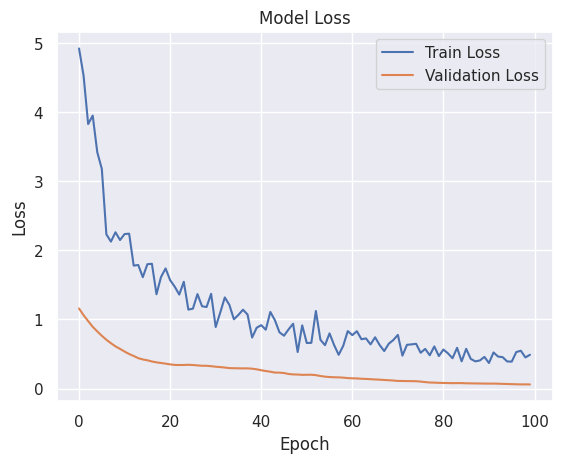

In [68]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [69]:
# Train the model
model.fit(X_train1, y_train1, epochs=100, batch_size=64, validation_data=(X_val1, y_val1), verbose=2)

Epoch 1/100
3/3 - 0s - 34ms/step - loss: 0.4326 - val_loss: 0.0576
Epoch 2/100
3/3 - 0s - 36ms/step - loss: 0.4859 - val_loss: 0.0576
Epoch 3/100
3/3 - 0s - 18ms/step - loss: 0.4709 - val_loss: 0.0575
Epoch 4/100
3/3 - 0s - 24ms/step - loss: 0.2923 - val_loss: 0.0578
Epoch 5/100
3/3 - 0s - 18ms/step - loss: 0.3359 - val_loss: 0.0576
Epoch 6/100
3/3 - 0s - 17ms/step - loss: 0.4095 - val_loss: 0.0576
Epoch 7/100
3/3 - 0s - 17ms/step - loss: 0.3593 - val_loss: 0.0580
Epoch 8/100
3/3 - 0s - 18ms/step - loss: 0.3678 - val_loss: 0.0578
Epoch 9/100
3/3 - 0s - 18ms/step - loss: 0.4687 - val_loss: 0.0570
Epoch 10/100
3/3 - 0s - 17ms/step - loss: 0.3532 - val_loss: 0.0572
Epoch 11/100
3/3 - 0s - 18ms/step - loss: 0.3230 - val_loss: 0.0573
Epoch 12/100
3/3 - 0s - 19ms/step - loss: 0.3741 - val_loss: 0.0571
Epoch 13/100
3/3 - 0s - 19ms/step - loss: 0.3394 - val_loss: 0.0576
Epoch 14/100
3/3 - 0s - 23ms/step - loss: 0.3448 - val_loss: 0.0574
Epoch 15/100
3/3 - 0s - 46ms/step - loss: 0.3137 - val_lo

In [71]:
from sklearn.metrics import mean_squared_error

# Evaluate the model on test data
y_pred = model.predict(X_test1)

# Transform predictions back to original scale
y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test1.reshape(-1, 1)).flatten()

# Calculate Mean Squared Error
mse = mean_squared_error(y_test_original, y_pred_original)
print('Mean Squared Error (Test Accuracy):', mse)

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test_original, y_pred_original)
print('Mean Absolute Error (MAE):', mae)

# Calculate Root Mean Squared Error
rmse = mean_squared_error(y_test_original, y_pred_original, squared=False)
print('Root Mean Squared Error (RMSE):', rmse)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Mean Squared Error (Test Accuracy): 3.265959759669257
Mean Absolute Error (MAE): 1.4015663414670712
Root Mean Squared Error (RMSE): 1.807196657718594


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


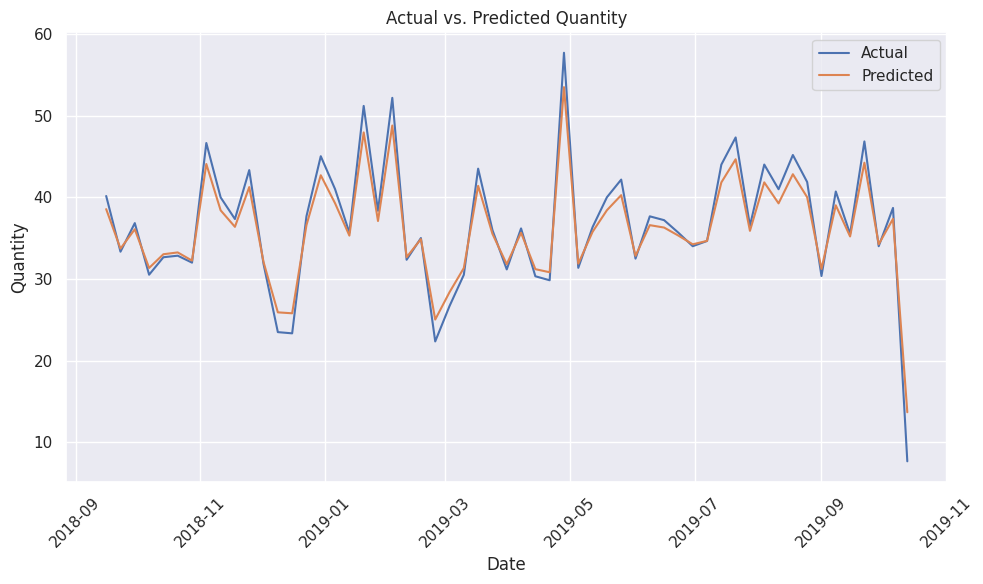

In [72]:
# Make predictions on the test data
predictions = model.predict(X_test1)

# Inverse transform the predictions
predicted_values = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()

# Inverse transform the actual values
actual_values = scaler_y.inverse_transform(y_test1.reshape(-1, 1)).flatten()

# Plot actual vs. predicted values with 'datum' on the x-axis
plt.figure(figsize=(10, 6))
plt.plot(test1['datum'], actual_values, label='Actual')
plt.plot(test1['datum'], predicted_values, label='Predicted')
plt.title('Actual vs. Predicted Quantity')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

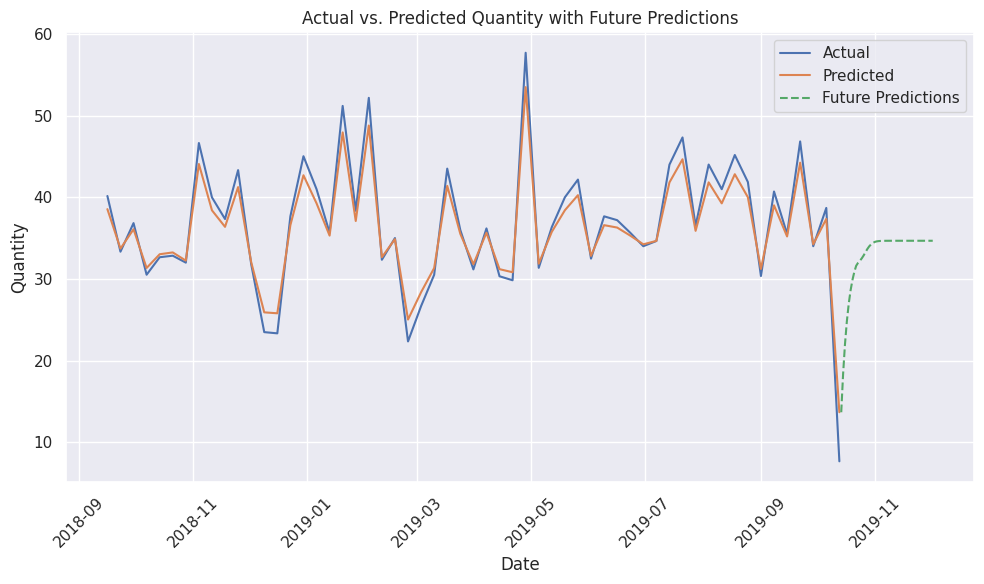

In [73]:
# Number of future time steps to predict
future_steps = 50  # Adjust as needed

# Prepare the last window of data from the test set to predict future values
last_window = X_test1[-1].reshape(1, -1)  # Reshape to match model input shape

# Predict future values iteratively
future_predictions = []
for _ in range(future_steps):
    # Predict the next value
    next_pred = model.predict(last_window)
    
    # Append the prediction to the list
    future_predictions.append(next_pred[0])
    
    # Update the last window by removing the first element and adding the prediction
    last_window = np.roll(last_window, -1)
    last_window[-1] = next_pred

# Inverse transform the predicted future values
future_predictions = scaler_y.inverse_transform(np.array(future_predictions).reshape(-1, 1)).flatten()

# Generate future dates for plotting
last_date = pd.to_datetime(test1['datum'].iloc[-1])
future_dates = [last_date + pd.DateOffset(days=i) for i in range(1, future_steps + 1)]

# Plot actual vs. predicted values with future predictions
plt.figure(figsize=(10, 6))
plt.plot(test1['datum'], actual_values, label='Actual')
plt.plot(test1['datum'], predicted_values, label='Predicted')
plt.plot(future_dates, future_predictions, label='Future Predictions', linestyle='--')
plt.title('Actual vs. Predicted Quantity with Future Predictions')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()


# M01AE

In [74]:
# Function to prepare data
def prepare_data(time_data, n_features):
    X, y = [], []
    for i in range(len(time_data)):
        end_ix = i + n_features
        if end_ix > (len(time_data) - 1):
            break
        seq_x, seq_y = time_data[i:end_ix], time_data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [75]:
# Splitting data into train and test sets
split_index = 245
train2 = df_new2.iloc[:split_index]
test2 = df_new2.iloc[split_index:]

In [76]:
X_train2 = train2.drop(['datum'], axis=1).values
y_train2 = train2['Quantity'].values
X_test2 = test2.drop(['datum'], axis=1).values
y_test2 = test2['Quantity'].values

In [77]:
# Standardize features
scaler = StandardScaler()
X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)

In [78]:
# Normalize target variable
scaler_y = StandardScaler()
y_train2 = scaler_y.fit_transform(y_train2.reshape(-1, 1)).flatten()
y_test2 = scaler_y.transform(y_test2.reshape(-1, 1)).flatten()

In [79]:
# Split the data
X_train2, X_val2, y_train2, y_val2 = train_test_split(X_train2, y_train2, test_size=0.3, random_state=42)

In [80]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras import regularizers

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train2.shape[1],), kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(1)
])


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 96 (384.00 B)

In [81]:
# Compile the model
model.compile(optimizer='adam', loss='mse')  # Using mean squared error for regression
# Train the model
history = model.fit(X_train2, y_train2, epochs=100, batch_size=32, validation_data=(X_val2, y_val2))

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 2.1354 - val_loss: 0.9617
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2962 - val_loss: 0.8746
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2883 - val_loss: 0.8111
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.0456 - val_loss: 0.7428
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8290 - val_loss: 0.6841
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7141 - val_loss: 0.6359
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.5294 - val_loss: 0.5961
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.6282 - val_loss: 0.5682
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5137 - val_loss: 0.5544
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3636 - val_loss: 0.5533
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3969 - val_loss: 0.5489
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.9045 - val_loss: 0.535

In [82]:
# Evaluate the model
train_loss2 = model.evaluate(X_train2, y_train2, verbose=0)
val_loss2 = model.evaluate(X_val2, y_val2, verbose=0)
print('Train Loss:', train_loss2)
print('Validation Loss:', val_loss2)

Train Loss: 0.08476362377405167
Validation Loss: 0.08120142668485641


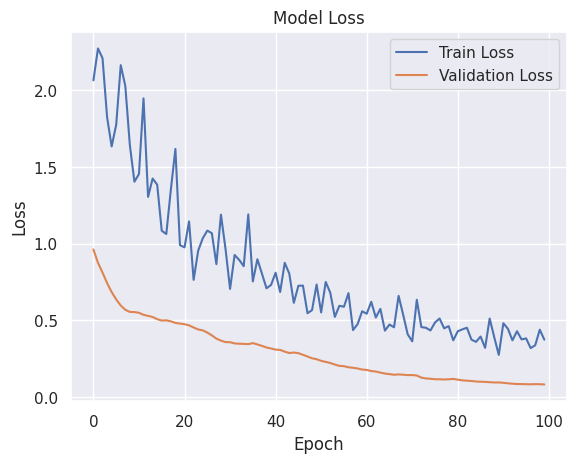

In [83]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# N02BA

In [84]:
# Train the model
model.fit(X_train2, y_train2, epochs=100, batch_size=64, validation_data=(X_val2, y_val2), verbose=2)

Epoch 1/100
3/3 - 0s - 34ms/step - loss: 0.2970 - val_loss: 0.0765
Epoch 2/100
3/3 - 0s - 31ms/step - loss: 0.3346 - val_loss: 0.0771
Epoch 3/100
3/3 - 0s - 18ms/step - loss: 0.3372 - val_loss: 0.0770
Epoch 4/100
3/3 - 0s - 18ms/step - loss: 0.3742 - val_loss: 0.0762
Epoch 5/100
3/3 - 0s - 18ms/step - loss: 0.3587 - val_loss: 0.0770
Epoch 6/100
3/3 - 0s - 20ms/step - loss: 0.3345 - val_loss: 0.0769
Epoch 7/100
3/3 - 0s - 26ms/step - loss: 0.4325 - val_loss: 0.0768
Epoch 8/100
3/3 - 0s - 18ms/step - loss: 0.4107 - val_loss: 0.0768
Epoch 9/100
3/3 - 0s - 20ms/step - loss: 0.2761 - val_loss: 0.0774
Epoch 10/100
3/3 - 0s - 18ms/step - loss: 0.4478 - val_loss: 0.0773
Epoch 11/100
3/3 - 0s - 18ms/step - loss: 0.3210 - val_loss: 0.0766
Epoch 12/100
3/3 - 0s - 18ms/step - loss: 0.3483 - val_loss: 0.0762
Epoch 13/100
3/3 - 0s - 21ms/step - loss: 0.3878 - val_loss: 0.0752
Epoch 14/100
3/3 - 0s - 18ms/step - loss: 0.2823 - val_loss: 0.0749
Epoch 15/100
3/3 - 0s - 20ms/step - loss: 0.3249 - val_lo

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


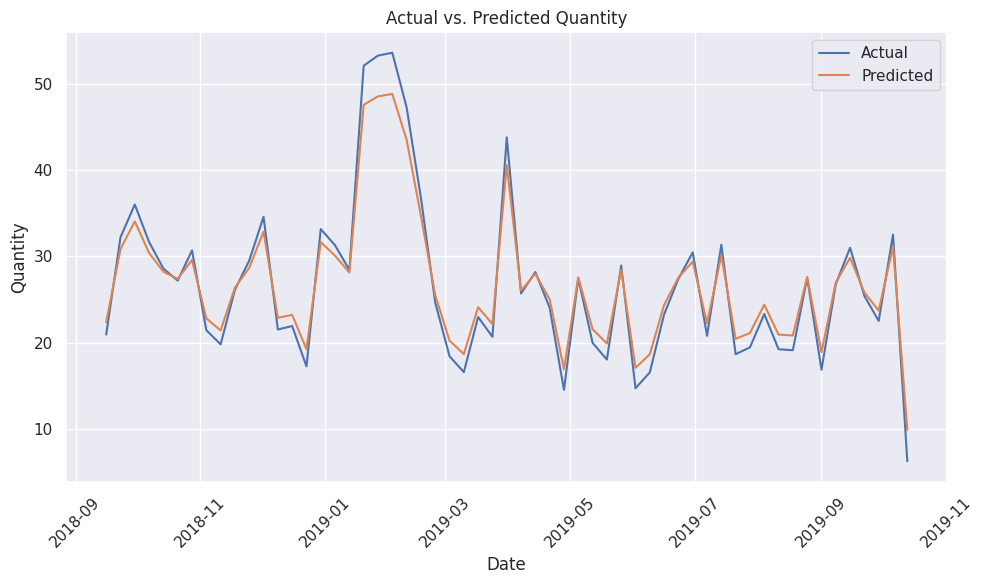

In [85]:
# Make predictions on the test data
predictions = model.predict(X_test2)

# Inverse transform the predictions
predicted_values = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()

# Inverse transform the actual values
actual_values = scaler_y.inverse_transform(y_test2.reshape(-1, 1)).flatten()

# Plot actual vs. predicted values with 'datum' on the x-axis
plt.figure(figsize=(10, 6))
plt.plot(test2['datum'], actual_values, label='Actual')
plt.plot(test2['datum'], predicted_values, label='Predicted')
plt.title('Actual vs. Predicted Quantity')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

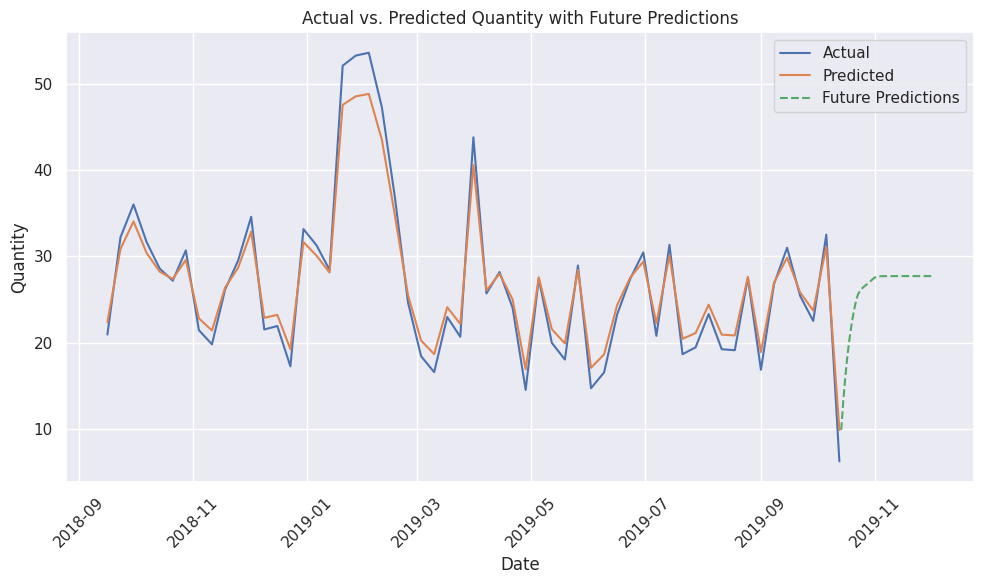

In [86]:
# Number of future time steps to predict
future_steps = 50  # Adjust as needed

# Prepare the last window of data from the test set to predict future values
last_window = X_test2[-1].reshape(1, -1)  # Reshape to match model input shape

# Predict future values iteratively while maintaining the trend
future_predictions = []
for _ in range(future_steps):
    # Predict the next value
    next_pred = model.predict(last_window)
    
    # Append the prediction to the list
    future_predictions.append(next_pred[0])
    
    # Extend the last window by adding the prediction at the end
    last_window = np.append(last_window[:, 1:], next_pred).reshape(1, -1)

# Inverse transform the predicted future values
future_predictions = scaler_y.inverse_transform(np.array(future_predictions).reshape(-1, 1)).flatten()

# Generate future dates for plotting
last_date = pd.to_datetime(test2['datum'].iloc[-1])
future_dates = [last_date + pd.DateOffset(days=i) for i in range(1, future_steps + 1)]

# Plot actual vs. predicted values with future predictions
plt.figure(figsize=(10, 6))
plt.plot(test2['datum'], actual_values, label='Actual')
plt.plot(test2['datum'], predicted_values, label='Predicted')
plt.plot(future_dates, future_predictions, label='Future Predictions', linestyle='--')
plt.title('Actual vs. Predicted Quantity with Future Predictions')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()


## N02BA

In [87]:
# Function to prepare data
def prepare_data(time_data, n_features):
    X, y = [], []
    for i in range(len(time_data)):
        end_ix = i + n_features
        if end_ix > (len(time_data) - 1):
            break
        seq_x, seq_y = time_data[i:end_ix], time_data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [88]:
# Splitting data into train and test sets
split_index = 245
train3 = df_new3.iloc[:split_index]
test3 = df_new3.iloc[split_index:]

In [89]:
X_train3 = train3.drop(['datum'], axis=1).values
y_train3 = train3['Quantity'].values
X_test3 = test3.drop(['datum'], axis=1).values
y_test3 = test3['Quantity'].values

In [90]:
# Standardize features
scaler = StandardScaler()
X_train3 = scaler.fit_transform(X_train3)
X_test3 = scaler.transform(X_test3)

In [91]:
# Normalize target variable
scaler_y = StandardScaler()
y_train3 = scaler_y.fit_transform(y_train3.reshape(-1, 1)).flatten()
y_test3 = scaler_y.transform(y_test3.reshape(-1, 1)).flatten()

In [92]:
# Split the data
X_train3, X_val3, y_train3, y_val3 = train_test_split(X_train3, y_train3, test_size=0.3, random_state=42)

In [93]:
def create_ann_model(input_shape, n_units=256, n_layers=3, dropout_rate=0.3):
    model = Sequential()
    # Reshape input data
    model.add(Flatten(input_shape=input_shape))
    # Add dense layers
    for i in range(n_layers):
        model.add(Dense(units=n_units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    model.add(Dense(1))  # Output layer
    return model

# Create the ANN model
n_features = X_train3.shape[1]
input_shape = (n_features, 1)
model = create_ann_model(input_shape)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,681 (530.00 KB)

 Trainable params: 134,145 (524.00 KB)

 Non-trainable params: 1,536 (6.00 KB)

In [94]:
# Compile the model
model.compile(optimizer='adam', loss='mse')  # Using mean squared error for regression
# Train the model
history = model.fit(X_train3, y_train3, epochs=100, batch_size=32, validation_data=(X_val3, y_val3))

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 3.6220 - val_loss: 0.6441
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8275 - val_loss: 0.6621
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.7944 - val_loss: 0.6190
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.7514 - val_loss: 0.6518
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.8146 - val_loss: 0.6239
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.4540 - val_loss: 0.6308
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.8991 - val_loss: 0.6480
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2571 - val_loss: 0.5996
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2124 - val_loss: 0.5861
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1437 - val_loss: 0.5980
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.5461 - val_loss: 0.5499
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2285 - val_lo

In [95]:
# Evaluate the model
train_loss3 = model.evaluate(X_train3, y_train3, verbose=0)
val_loss3 = model.evaluate(X_val3, y_val3, verbose=0)
print('Train Loss:', train_loss3)
print('Validation Loss:', val_loss3)

Train Loss: 0.03460176661610603
Validation Loss: 0.025400295853614807


In [96]:
# Train the model
model.fit(X_train3, y_train3, epochs=100, batch_size=64, validation_data=(X_val3, y_val3), verbose=2)

Epoch 1/100
3/3 - 0s - 39ms/step - loss: 0.1724 - val_loss: 0.0268
Epoch 2/100
3/3 - 0s - 22ms/step - loss: 0.1292 - val_loss: 0.0302
Epoch 3/100
3/3 - 0s - 47ms/step - loss: 0.1890 - val_loss: 0.0308
Epoch 4/100
3/3 - 0s - 27ms/step - loss: 0.1161 - val_loss: 0.0222
Epoch 5/100
3/3 - 0s - 41ms/step - loss: 0.1705 - val_loss: 0.0148
Epoch 6/100
3/3 - 0s - 23ms/step - loss: 0.1345 - val_loss: 0.0102
Epoch 7/100
3/3 - 0s - 21ms/step - loss: 0.0945 - val_loss: 0.0060
Epoch 8/100
3/3 - 0s - 47ms/step - loss: 0.1273 - val_loss: 0.0032
Epoch 9/100
3/3 - 0s - 21ms/step - loss: 0.1110 - val_loss: 0.0041
Epoch 10/100
3/3 - 0s - 23ms/step - loss: 0.1205 - val_loss: 0.0053
Epoch 11/100
3/3 - 0s - 23ms/step - loss: 0.1906 - val_loss: 0.0105
Epoch 12/100
3/3 - 0s - 45ms/step - loss: 0.1434 - val_loss: 0.0126
Epoch 13/100
3/3 - 0s - 27ms/step - loss: 0.1168 - val_loss: 0.0175
Epoch 14/100
3/3 - 0s - 41ms/step - loss: 0.1594 - val_loss: 0.0213
Epoch 15/100
3/3 - 0s - 22ms/step - loss: 0.1369 - val_lo

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


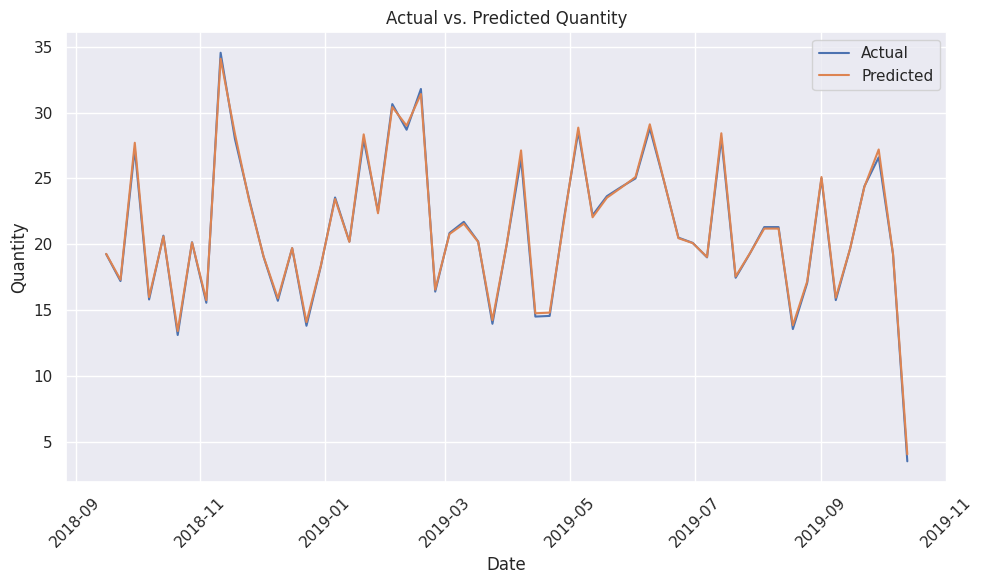

In [97]:
# Make predictions on the test data
predictions = model.predict(X_test3)

# Inverse transform the predictions
predicted_values = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()

# Inverse transform the actual values
actual_values = scaler_y.inverse_transform(y_test3.reshape(-1, 1)).flatten()

# Plot actual vs. predicted values with 'datum' on the x-axis
plt.figure(figsize=(10, 6))
plt.plot(test3['datum'], actual_values, label='Actual')
plt.plot(test3['datum'], predicted_values, label='Predicted')
plt.title('Actual vs. Predicted Quantity')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

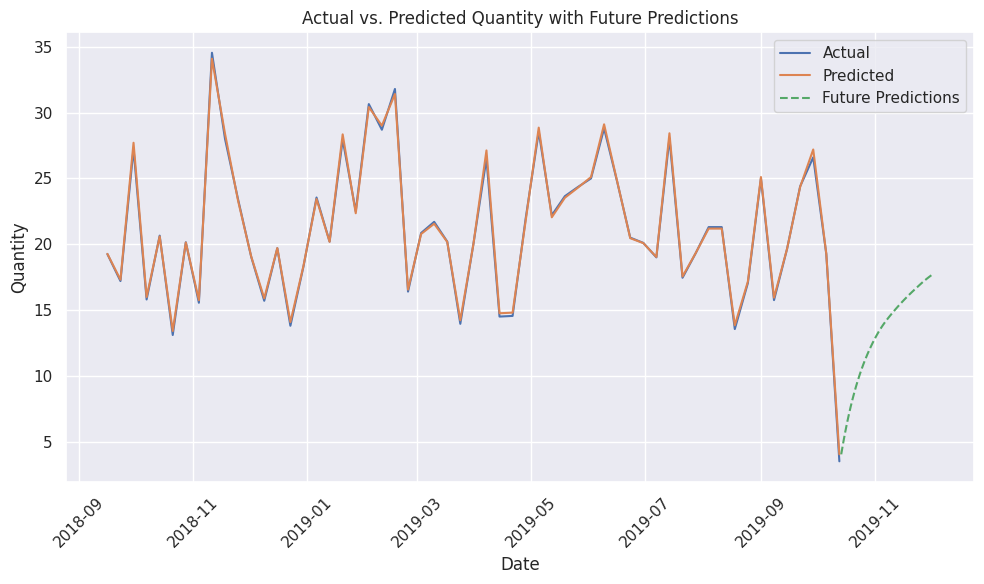

In [98]:
# Number of future time steps to predict
future_steps = 50  # Adjust as needed

# Prepare the last window of data from the test set to predict future values
last_window = X_test3[-1].reshape(1, -1)  # Reshape to match model input shape

# Predict future values iteratively while maintaining the trend
future_predictions = []
for _ in range(future_steps):
    # Predict the next value
    next_pred = model.predict(last_window)
    
    # Append the prediction to the list
    future_predictions.append(next_pred[0])
    
    # Extend the last window by adding the prediction at the end
    last_window = np.append(last_window[:, 1:], next_pred).reshape(1, -1)

# Inverse transform the predicted future values
future_predictions = scaler_y.inverse_transform(np.array(future_predictions).reshape(-1, 1)).flatten()

# Generate future dates for plotting
last_date = pd.to_datetime(test3['datum'].iloc[-1])
future_dates = [last_date + pd.DateOffset(days=i) for i in range(1, future_steps + 1)]

# Plot actual vs. predicted values with future predictions
plt.figure(figsize=(10, 6))
plt.plot(test3['datum'], actual_values, label='Actual')
plt.plot(test3['datum'], predicted_values, label='Predicted')
plt.plot(future_dates, future_predictions, label='Future Predictions', linestyle='--')
plt.title('Actual vs. Predicted Quantity with Future Predictions')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()


## N02BE

In [99]:
# Function to prepare data
def prepare_data(time_data, n_features):
    X, y = [], []
    for i in range(len(time_data)):
        end_ix = i + n_features
        if end_ix > (len(time_data) - 1):
            break
        seq_x, seq_y = time_data[i:end_ix], time_data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [100]:
# Splitting data into train and test sets
split_index = 245
train4 = df_new4.iloc[:split_index]
test4 = df_new4.iloc[split_index:]

In [101]:
X_train4 = train4.drop(['datum'], axis=1).values
y_train4 = train4['Quantity'].values
X_test4 = test4.drop(['datum'], axis=1).values
y_test4 = test4['Quantity'].values

In [102]:
# Standardize features
scaler = StandardScaler()
X_train4 = scaler.fit_transform(X_train4)
X_test4 = scaler.transform(X_test4)

In [103]:
# Normalize target variable
scaler_y = StandardScaler()
y_train4 = scaler_y.fit_transform(y_train4.reshape(-1, 1)).flatten()
y_test4 = scaler_y.transform(y_test4.reshape(-1, 1)).flatten()

In [104]:
# Split the data
X_train4, X_val4, y_train4, y_val4 = train_test_split(X_train4, y_train4, test_size=0.3, random_state=42)

In [105]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras import regularizers

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train4.shape[1],), kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(1)
])


model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 96 (384.00 B)

In [106]:
# Compile the model
model.compile(optimizer='adam', loss='mse')  # Using mean squared error for regression
# Train the model
history = model.fit(X_train4, y_train4, epochs=100, batch_size=32, validation_data=(X_val4, y_val4))

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 2.0467 - val_loss: 0.9902
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3749 - val_loss: 0.9356
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4476 - val_loss: 0.8967
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3338 - val_loss: 0.8568
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2894 - val_loss: 0.8175
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3208 - val_loss: 0.7831
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4138 - val_loss: 0.7550
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9151 - val_loss: 0.7396
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1602 - val_loss: 0.7254
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1235 - val_loss: 0.7119
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8376 - val_loss: 0.6994
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1495 - val_loss: 0.6843

In [107]:
# Evaluate the model
train_loss4 = model.evaluate(X_train4, y_train4, verbose=0)
val_loss4 = model.evaluate(X_val4, y_val4, verbose=0)
print('Train Loss:', train_loss4)
print('Validation Loss:', val_loss4)

Train Loss: 0.11307369917631149
Validation Loss: 0.11586352437734604


In [108]:
# Train the model
model.fit(X_train4, y_train4, epochs=100, batch_size=64, validation_data=(X_val4, y_val4), verbose=2)

Epoch 1/100
3/3 - 0s - 37ms/step - loss: 0.2803 - val_loss: 0.1126
Epoch 2/100
3/3 - 0s - 18ms/step - loss: 0.2145 - val_loss: 0.1111
Epoch 3/100
3/3 - 0s - 19ms/step - loss: 0.2684 - val_loss: 0.1094
Epoch 4/100
3/3 - 0s - 20ms/step - loss: 0.3555 - val_loss: 0.1048
Epoch 5/100
3/3 - 0s - 19ms/step - loss: 0.2656 - val_loss: 0.1033
Epoch 6/100
3/3 - 0s - 19ms/step - loss: 0.2897 - val_loss: 0.1020
Epoch 7/100
3/3 - 0s - 19ms/step - loss: 0.2494 - val_loss: 0.1018
Epoch 8/100
3/3 - 0s - 20ms/step - loss: 0.2727 - val_loss: 0.1009
Epoch 9/100
3/3 - 0s - 19ms/step - loss: 0.3314 - val_loss: 0.0999
Epoch 10/100
3/3 - 0s - 19ms/step - loss: 0.2581 - val_loss: 0.0991
Epoch 11/100
3/3 - 0s - 19ms/step - loss: 0.2611 - val_loss: 0.0984
Epoch 12/100
3/3 - 0s - 20ms/step - loss: 0.2753 - val_loss: 0.0974
Epoch 13/100
3/3 - 0s - 19ms/step - loss: 0.3165 - val_loss: 0.0955
Epoch 14/100
3/3 - 0s - 19ms/step - loss: 0.2879 - val_loss: 0.0939
Epoch 15/100
3/3 - 0s - 20ms/step - loss: 0.2266 - val_lo

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


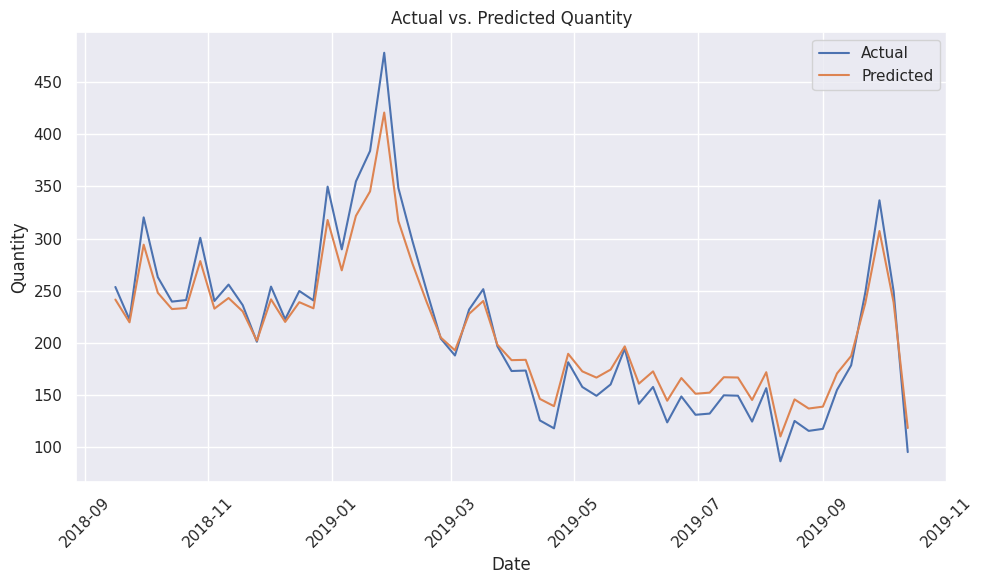

In [109]:
# Make predictions on the test data
predictions = model.predict(X_test4)

# Inverse transform the predictions
predicted_values = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()

# Inverse transform the actual values
actual_values = scaler_y.inverse_transform(y_test4.reshape(-1, 1)).flatten()

# Plot actual vs. predicted values with 'datum' on the x-axis
plt.figure(figsize=(10, 6))
plt.plot(test4['datum'], actual_values, label='Actual')
plt.plot(test4['datum'], predicted_values, label='Predicted')
plt.title('Actual vs. Predicted Quantity')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

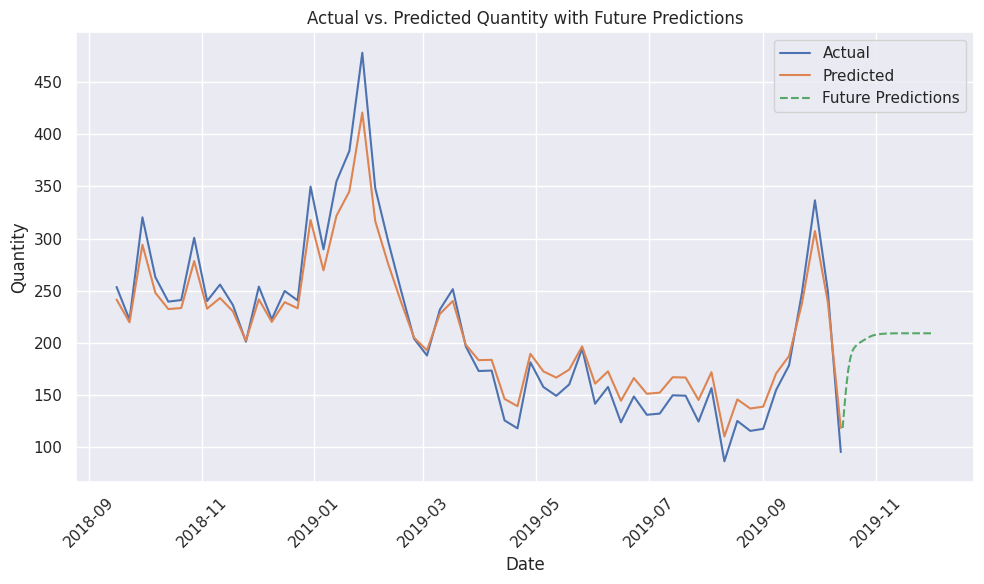

In [110]:
# Number of future time steps to predict
future_steps = 50  # Adjust as needed

# Prepare the last window of data from the test set to predict future values
last_window = X_test4[-1].reshape(1, -1)  # Reshape to match model input shape

# Predict future values iteratively while maintaining the trend
future_predictions = []
for _ in range(future_steps):
    # Predict the next value
    next_pred = model.predict(last_window)
    
    # Append the prediction to the list
    future_predictions.append(next_pred[0])
    
    # Extend the last window by adding the prediction at the end
    last_window = np.append(last_window[:, 1:], next_pred).reshape(1, -1)

# Inverse transform the predicted future values
future_predictions = scaler_y.inverse_transform(np.array(future_predictions).reshape(-1, 1)).flatten()

# Generate future dates for plotting
last_date = pd.to_datetime(test4['datum'].iloc[-1])
future_dates = [last_date + pd.DateOffset(days=i) for i in range(1, future_steps + 1)]

# Plot actual vs. predicted values with future predictions
plt.figure(figsize=(10, 6))
plt.plot(test4['datum'], actual_values, label='Actual')
plt.plot(test4['datum'], predicted_values, label='Predicted')
plt.plot(future_dates, future_predictions, label='Future Predictions', linestyle='--')
plt.title('Actual vs. Predicted Quantity with Future Predictions')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()


## N05B

In [111]:
# Function to prepare data
def prepare_data(time_data, n_features):
    X, y = [], []
    for i in range(len(time_data)):
        end_ix = i + n_features
        if end_ix > (len(time_data) - 1):
            break
        seq_x, seq_y = time_data[i:end_ix], time_data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [112]:
# Splitting data into train and test sets
split_index = 245
train5 = df_new5.iloc[:split_index]
test5 = df_new5.iloc[split_index:]

In [113]:
X_train5 = train5.drop(['datum'], axis=1).values
y_train5 = train5['Quantity'].values
X_test5 = test5.drop(['datum'], axis=1).values
y_test5 = test5['Quantity'].values

In [114]:
# Standardize features
scaler = StandardScaler()
X_train5 = scaler.fit_transform(X_train5)
X_test5 = scaler.transform(X_test5)

In [115]:
# Normalize target variable
scaler_y = StandardScaler()
y_train5 = scaler_y.fit_transform(y_train5.reshape(-1, 1)).flatten()
y_test5 = scaler_y.transform(y_test5.reshape(-1, 1)).flatten()

In [116]:
# Split the data
X_train5, X_val5, y_train5, y_val5 = train_test_split(X_train5, y_train5, test_size=0.3, random_state=42)

In [117]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras import regularizers

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train5.shape[1],), kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(1)
])


model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 96 (384.00 B)

In [118]:
# Compile the model
model.compile(optimizer='adam', loss='mse')  # Using mean squared error for regression
# Train the model
history = model.fit(X_train5, y_train5, epochs=100, batch_size=32, validation_data=(X_val5, y_val5))

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 1.8994 - val_loss: 0.9104
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6371 - val_loss: 0.8721
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0821 - val_loss: 0.8391
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2126 - val_loss: 0.8093
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9210 - val_loss: 0.7885
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0578 - val_loss: 0.7657
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7545 - val_loss: 0.7406
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7005 - val_loss: 0.7164
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7922 - val_loss: 0.6933
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7459 - val_loss: 0.6757
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7200 - val_loss: 0.6554
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6986 - val_loss: 0.6356

In [119]:
# Evaluate the model
train_loss5 = model.evaluate(X_train5, y_train5, verbose=0)
val_loss5 = model.evaluate(X_val5, y_val5, verbose=0)
print('Train Loss:', train_loss5)
print('Validation Loss:', val_loss5)

Train Loss: 0.10315550118684769
Validation Loss: 0.10990730673074722


In [120]:
# Train the model
model.fit(X_train5, y_train5, epochs=100, batch_size=64, validation_data=(X_val5, y_val5), verbose=2)

Epoch 1/100
3/3 - 0s - 36ms/step - loss: 0.2060 - val_loss: 0.1101
Epoch 2/100
3/3 - 0s - 30ms/step - loss: 0.2340 - val_loss: 0.1101
Epoch 3/100
3/3 - 0s - 18ms/step - loss: 0.2405 - val_loss: 0.1092
Epoch 4/100
3/3 - 0s - 19ms/step - loss: 0.2729 - val_loss: 0.1071
Epoch 5/100
3/3 - 0s - 20ms/step - loss: 0.2525 - val_loss: 0.1063
Epoch 6/100
3/3 - 0s - 20ms/step - loss: 0.2600 - val_loss: 0.1066
Epoch 7/100
3/3 - 0s - 18ms/step - loss: 0.2332 - val_loss: 0.1050
Epoch 8/100
3/3 - 0s - 18ms/step - loss: 0.2342 - val_loss: 0.1049
Epoch 9/100
3/3 - 0s - 24ms/step - loss: 0.2407 - val_loss: 0.1025
Epoch 10/100
3/3 - 0s - 19ms/step - loss: 0.1583 - val_loss: 0.1009
Epoch 11/100
3/3 - 0s - 19ms/step - loss: 0.2867 - val_loss: 0.0996
Epoch 12/100
3/3 - 0s - 20ms/step - loss: 0.2198 - val_loss: 0.0971
Epoch 13/100
3/3 - 0s - 18ms/step - loss: 0.2430 - val_loss: 0.0962
Epoch 14/100
3/3 - 0s - 20ms/step - loss: 0.2139 - val_loss: 0.0949
Epoch 15/100
3/3 - 0s - 20ms/step - loss: 0.2203 - val_lo

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


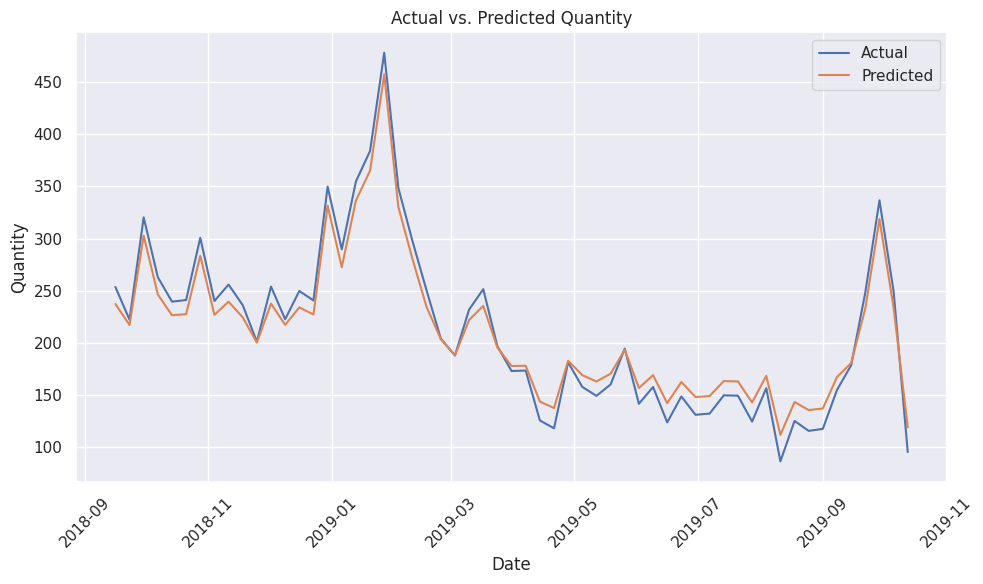

In [121]:
# Make predictions on the test data
predictions = model.predict(X_test5)

# Inverse transform the predictions
predicted_values = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()

# Inverse transform the actual values
actual_values = scaler_y.inverse_transform(y_test5.reshape(-1, 1)).flatten()

# Plot actual vs. predicted values with 'datum' on the x-axis
plt.figure(figsize=(10, 6))
plt.plot(test5['datum'], actual_values, label='Actual')
plt.plot(test5['datum'], predicted_values, label='Predicted')
plt.title('Actual vs. Predicted Quantity')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

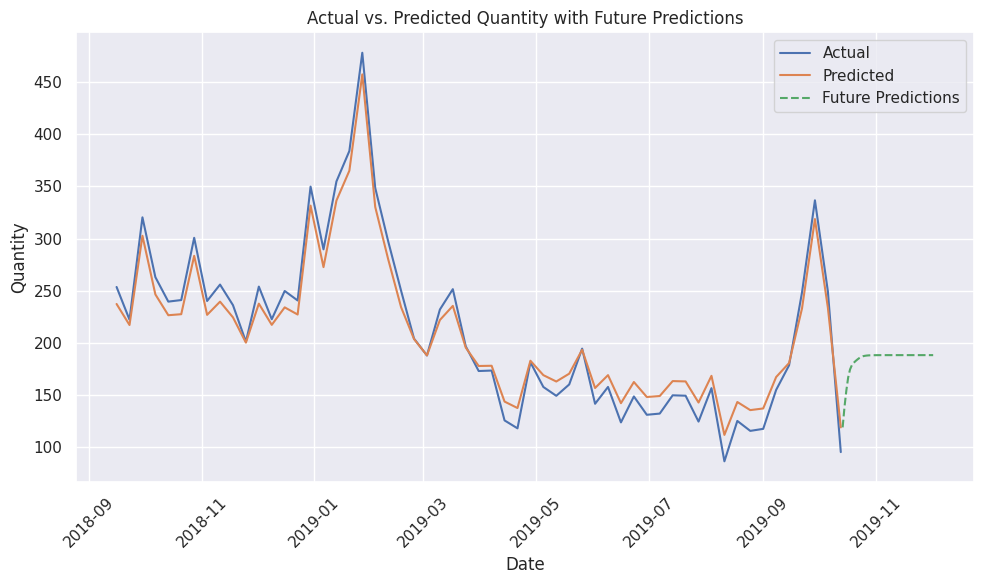

In [122]:
# Number of future time steps to predict
future_steps = 50  # Adjust as needed

# Prepare the last window of data from the test set to predict future values
last_window = X_test5[-1].reshape(1, -1)  # Reshape to match model input shape

# Predict future values iteratively while maintaining the trend
future_predictions = []
for _ in range(future_steps):
    # Predict the next value
    next_pred = model.predict(last_window)
    
    # Append the prediction to the list
    future_predictions.append(next_pred[0])
    
    # Extend the last window by adding the prediction at the end
    last_window = np.append(last_window[:, 1:], next_pred).reshape(1, -1)

# Inverse transform the predicted future values
future_predictions = scaler_y.inverse_transform(np.array(future_predictions).reshape(-1, 1)).flatten()

# Generate future dates for plotting
last_date = pd.to_datetime(test5['datum'].iloc[-1])
future_dates = [last_date + pd.DateOffset(days=i) for i in range(1, future_steps + 1)]

# Plot actual vs. predicted values with future predictions
plt.figure(figsize=(10, 6))
plt.plot(test5['datum'], actual_values, label='Actual')
plt.plot(test5['datum'], predicted_values, label='Predicted')
plt.plot(future_dates, future_predictions, label='Future Predictions', linestyle='--')
plt.title('Actual vs. Predicted Quantity with Future Predictions')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()


## N05C

In [123]:
# Function to prepare data
def prepare_data(time_data, n_features):
    X, y = [], []
    for i in range(len(time_data)):
        end_ix = i + n_features
        if end_ix > (len(time_data) - 1):
            break
        seq_x, seq_y = time_data[i:end_ix], time_data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [124]:
# Splitting data into train and test sets
split_index = 245
train6 = df_new6.iloc[:split_index]
test6 = df_new6.iloc[split_index:]

In [125]:
X_train6 = train6.drop(['datum'], axis=1).values
y_train6 = train6['Quantity'].values
X_test6 = test6.drop(['datum'], axis=1).values
y_test6 = test6['Quantity'].values

In [126]:
# Standardize features
scaler = StandardScaler()
X_train6 = scaler.fit_transform(X_train6)
X_test6 = scaler.transform(X_test6)

In [127]:
# Normalize target variable
scaler_y = StandardScaler()
y_train6 = scaler_y.fit_transform(y_train6.reshape(-1, 1)).flatten()
y_test6 = scaler_y.transform(y_test6.reshape(-1, 1)).flatten()

In [128]:
# Split the data
X_train6, X_val6, y_train6, y_val6 = train_test_split(X_train6, y_train6, test_size=0.3, random_state=42)

In [129]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras import regularizers

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train6.shape[1],), kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(1)
])


model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 96 (384.00 B)

In [130]:
# Compile the model
model.compile(optimizer='adam', loss='mse')  # Using mean squared error for regression
# Train the model
history = model.fit(X_train6, y_train6, epochs=100, batch_size=32, validation_data=(X_val6, y_val6))

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 1.9524 - val_loss: 0.9900
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.3411 - val_loss: 0.9646
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.3172 - val_loss: 0.9475
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.0940 - val_loss: 0.9281
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.0572 - val_loss: 0.9107
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.9534 - val_loss: 0.8800
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5701 - val_loss: 0.8578
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9791 - val_loss: 0.8369
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3821 - val_loss: 0.8162
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8140 - val_loss: 0.7955
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7599 - val_loss: 0.7798
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7656 - val_loss: 0.761

In [131]:
# Evaluate the model
train_loss6 = model.evaluate(X_train6, y_train6, verbose=0)
val_loss6 = model.evaluate(X_val6, y_val6, verbose=0)
print('Train Loss:', train_loss6)
print('Validation Loss:', val_loss6)

Train Loss: 0.11234599351882935
Validation Loss: 0.1334875077009201


In [132]:
# Train the model
model.fit(X_train6, y_train6, epochs=100, batch_size=64, validation_data=(X_val6, y_val6), verbose=2)

Epoch 1/100
3/3 - 0s - 35ms/step - loss: 0.3066 - val_loss: 0.1516
Epoch 2/100
3/3 - 0s - 22ms/step - loss: 0.3731 - val_loss: 0.1506
Epoch 3/100
3/3 - 0s - 19ms/step - loss: 0.3486 - val_loss: 0.1514
Epoch 4/100
3/3 - 0s - 20ms/step - loss: 0.2936 - val_loss: 0.1508
Epoch 5/100
3/3 - 0s - 22ms/step - loss: 0.2669 - val_loss: 0.1482
Epoch 6/100
3/3 - 0s - 18ms/step - loss: 0.3556 - val_loss: 0.1443
Epoch 7/100
3/3 - 0s - 17ms/step - loss: 0.3698 - val_loss: 0.1430
Epoch 8/100
3/3 - 0s - 18ms/step - loss: 0.3586 - val_loss: 0.1410
Epoch 9/100
3/3 - 0s - 18ms/step - loss: 0.3581 - val_loss: 0.1401
Epoch 10/100
3/3 - 0s - 18ms/step - loss: 0.3147 - val_loss: 0.1369
Epoch 11/100
3/3 - 0s - 17ms/step - loss: 0.4479 - val_loss: 0.1338
Epoch 12/100
3/3 - 0s - 18ms/step - loss: 0.3169 - val_loss: 0.1314
Epoch 13/100
3/3 - 0s - 21ms/step - loss: 0.4145 - val_loss: 0.1304
Epoch 14/100
3/3 - 0s - 19ms/step - loss: 0.3028 - val_loss: 0.1287
Epoch 15/100
3/3 - 0s - 20ms/step - loss: 0.3366 - val_lo

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


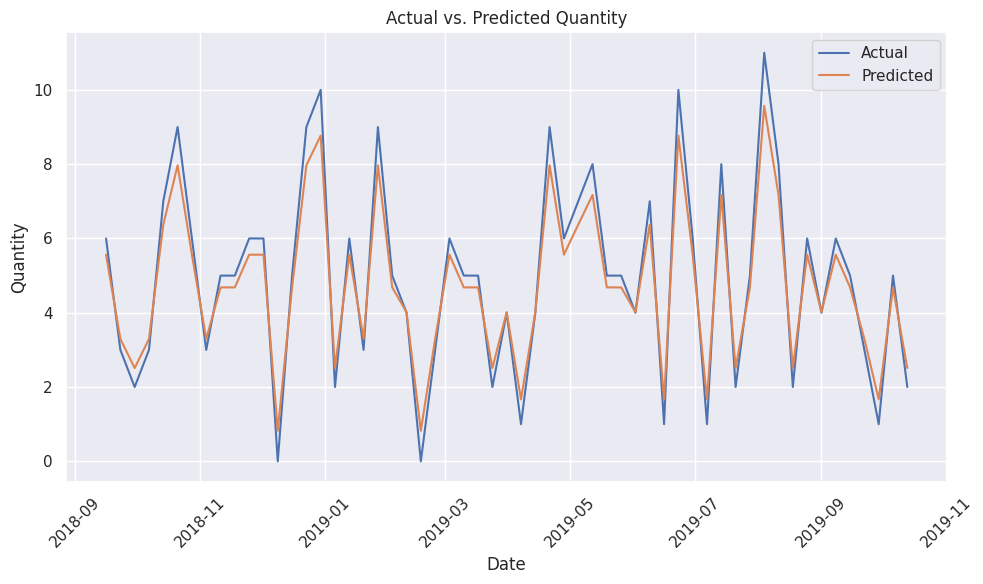

In [133]:
# Make predictions on the test data
predictions = model.predict(X_test6)

# Inverse transform the predictions
predicted_values = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()

# Inverse transform the actual values
actual_values = scaler_y.inverse_transform(y_test6.reshape(-1, 1)).flatten()

# Plot actual vs. predicted values with 'datum' on the x-axis
plt.figure(figsize=(10, 6))
plt.plot(test6['datum'], actual_values, label='Actual')
plt.plot(test6['datum'], predicted_values, label='Predicted')
plt.title('Actual vs. Predicted Quantity')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

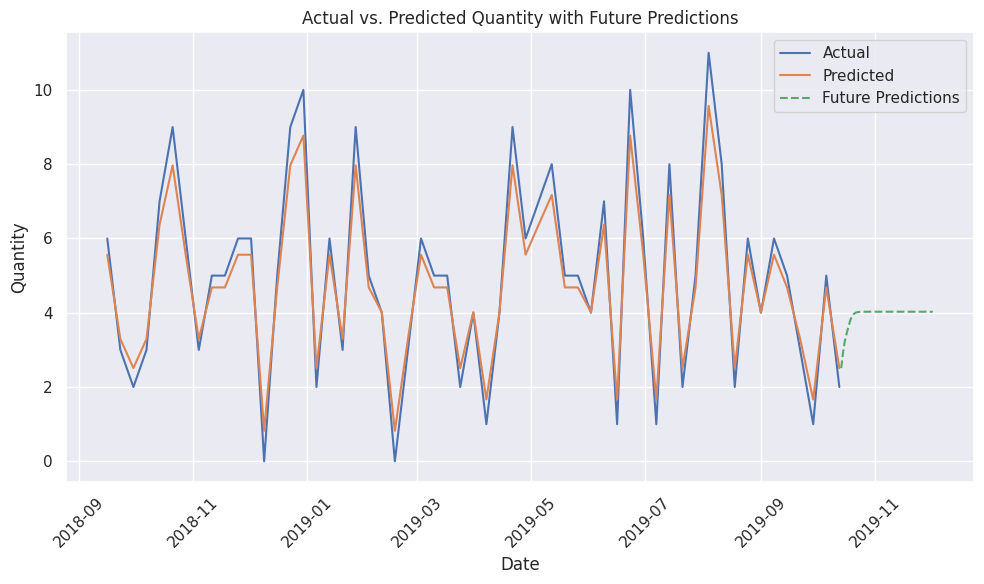

In [134]:
# Number of future time steps to predict
future_steps = 50  # Adjust as needed

# Prepare the last window of data from the test set to predict future values
last_window = X_test6[-1].reshape(1, -1)  # Reshape to match model input shape

# Predict future values iteratively while maintaining the trend
future_predictions = []
for _ in range(future_steps):
    # Predict the next value
    next_pred = model.predict(last_window)
    
    # Append the prediction to the list
    future_predictions.append(next_pred[0])
    
    # Extend the last window by adding the prediction at the end
    last_window = np.append(last_window[:, 1:], next_pred).reshape(1, -1)

# Inverse transform the predicted future values
future_predictions = scaler_y.inverse_transform(np.array(future_predictions).reshape(-1, 1)).flatten()

# Generate future dates for plotting
last_date = pd.to_datetime(test6['datum'].iloc[-1])
future_dates = [last_date + pd.DateOffset(days=i) for i in range(1, future_steps + 1)]

# Plot actual vs. predicted values with future predictions
plt.figure(figsize=(10, 6))
plt.plot(test6['datum'], actual_values, label='Actual')
plt.plot(test6['datum'], predicted_values, label='Predicted')
plt.plot(future_dates, future_predictions, label='Future Predictions', linestyle='--')
plt.title('Actual vs. Predicted Quantity with Future Predictions')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()


## R03

In [135]:
# Function to prepare data
def prepare_data(time_data, n_features):
    X, y = [], []
    for i in range(len(time_data)):
        end_ix = i + n_features
        if end_ix > (len(time_data) - 1):
            break
        seq_x, seq_y = time_data[i:end_ix], time_data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [136]:
# Splitting data into train and test sets
split_index = 245
train7 = df_new7.iloc[:split_index]
test7 = df_new7.iloc[split_index:]

In [137]:
X_train7 = train7.drop(['datum'], axis=1).values
y_train7 = train7['Quantity'].values
X_test7 = test7.drop(['datum'], axis=1).values
y_test7 = test7['Quantity'].values

In [138]:
# Standardize features
scaler = StandardScaler()
X_train7 = scaler.fit_transform(X_train7)
X_test7 = scaler.transform(X_test7)

In [139]:
# Normalize target variable
scaler_y = StandardScaler()
y_train7 = scaler_y.fit_transform(y_train7.reshape(-1, 1)).flatten()
y_test7 = scaler_y.transform(y_test7.reshape(-1, 1)).flatten()

In [140]:
# Split the data
X_train7, X_val7, y_train7, y_val7 = train_test_split(X_train7, y_train7, test_size=0.3, random_state=42)

In [141]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras import regularizers

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train7.shape[1],), kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(1)
])


model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 96 (384.00 B)

In [142]:
# Compile the model
model.compile(optimizer='adam', loss='mse')  # Using mean squared error for regression
# Train the model
history = model.fit(X_train7, y_train7, epochs=100, batch_size=32, validation_data=(X_val7, y_val7))

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 2.6610 - val_loss: 1.6720
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.0664 - val_loss: 1.5963
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.9100 - val_loss: 1.5227
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7241 - val_loss: 1.4508
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5706 - val_loss: 1.3778
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1805 - val_loss: 1.3102
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0906 - val_loss: 1.2553
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.3353 - val_loss: 1.1972
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2634 - val_loss: 1.1392
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9457 - val_loss: 1.0997
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0766 - val_loss: 1.0523
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9973 - val_loss: 1.00

In [143]:
# Evaluate the model
train_loss7 = model.evaluate(X_train7, y_train7, verbose=0)
val_loss7 = model.evaluate(X_val7, y_val7, verbose=0)
print('Train Loss:', train_loss7)
print('Validation Loss:', val_loss7)

Train Loss: 0.0936528742313385
Validation Loss: 0.1314123272895813


In [144]:
# Train the model
model.fit(X_train7, y_train7, epochs=100, batch_size=64, validation_data=(X_val7, y_val7), verbose=2)

Epoch 1/100
3/3 - 0s - 36ms/step - loss: 0.2986 - val_loss: 0.1407
Epoch 2/100
3/3 - 0s - 28ms/step - loss: 0.2090 - val_loss: 0.1398
Epoch 3/100
3/3 - 0s - 19ms/step - loss: 0.2831 - val_loss: 0.1377
Epoch 4/100
3/3 - 0s - 18ms/step - loss: 0.2055 - val_loss: 0.1346
Epoch 5/100
3/3 - 0s - 18ms/step - loss: 0.2709 - val_loss: 0.1330
Epoch 6/100
3/3 - 0s - 18ms/step - loss: 0.2281 - val_loss: 0.1310
Epoch 7/100
3/3 - 0s - 25ms/step - loss: 0.2804 - val_loss: 0.1289
Epoch 8/100
3/3 - 0s - 18ms/step - loss: 0.2506 - val_loss: 0.1277
Epoch 9/100
3/3 - 0s - 19ms/step - loss: 0.2910 - val_loss: 0.1253
Epoch 10/100
3/3 - 0s - 19ms/step - loss: 0.2763 - val_loss: 0.1239
Epoch 11/100
3/3 - 0s - 19ms/step - loss: 0.2009 - val_loss: 0.1252
Epoch 12/100
3/3 - 0s - 20ms/step - loss: 0.2334 - val_loss: 0.1247
Epoch 13/100
3/3 - 0s - 24ms/step - loss: 0.2416 - val_loss: 0.1248
Epoch 14/100
3/3 - 0s - 42ms/step - loss: 0.2498 - val_loss: 0.1235
Epoch 15/100
3/3 - 0s - 20ms/step - loss: 0.2572 - val_lo

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


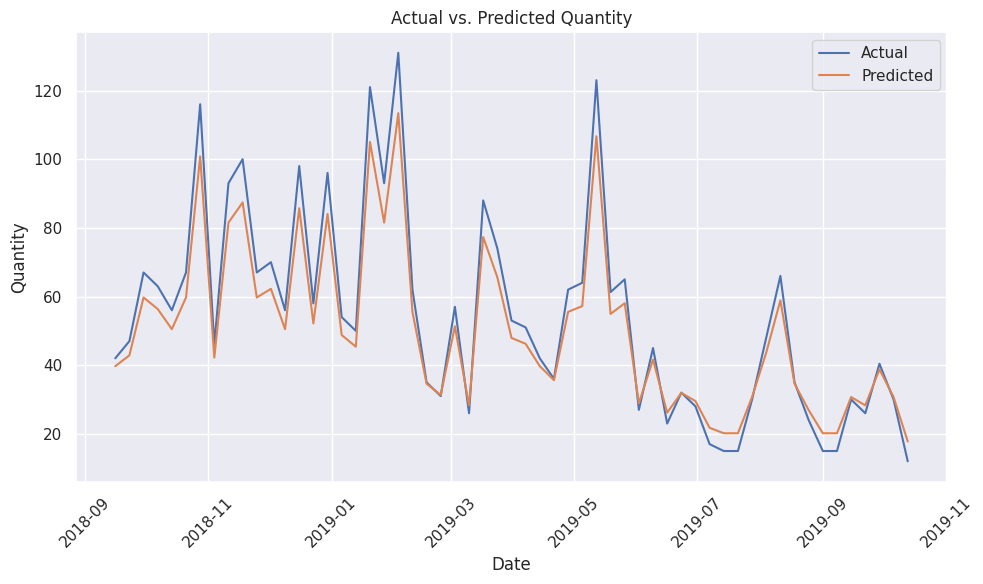

In [145]:
# Make predictions on the test data
predictions = model.predict(X_test7)

# Inverse transform the predictions
predicted_values = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()

# Inverse transform the actual values
actual_values = scaler_y.inverse_transform(y_test7.reshape(-1, 1)).flatten()

# Plot actual vs. predicted values with 'datum' on the x-axis
plt.figure(figsize=(10, 6))
plt.plot(test7['datum'], actual_values, label='Actual')
plt.plot(test7['datum'], predicted_values, label='Predicted')
plt.title('Actual vs. Predicted Quantity')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

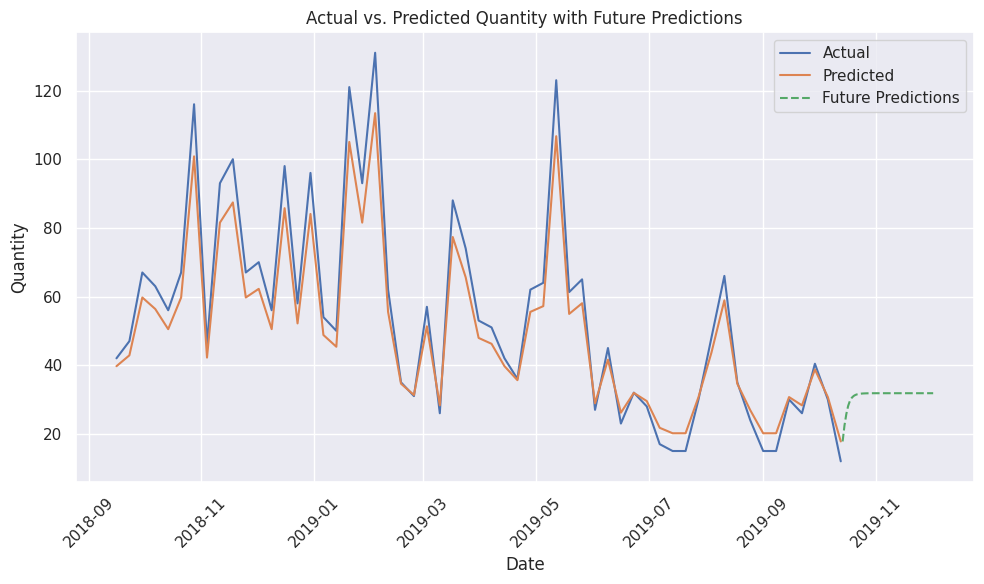

In [146]:
# Number of future time steps to predict
future_steps = 50  # Adjust as needed

# Prepare the last window of data from the test set to predict future values
last_window = X_test7[-1].reshape(1, -1)  # Reshape to match model input shape

# Predict future values iteratively while maintaining the trend
future_predictions = []
for _ in range(future_steps):
    # Predict the next value
    next_pred = model.predict(last_window)
    
    # Append the prediction to the list
    future_predictions.append(next_pred[0])
    
    # Extend the last window by adding the prediction at the end
    last_window = np.append(last_window[:, 1:], next_pred).reshape(1, -1)

# Inverse transform the predicted future values
future_predictions = scaler_y.inverse_transform(np.array(future_predictions).reshape(-1, 1)).flatten()

# Generate future dates for plotting
last_date = pd.to_datetime(test7['datum'].iloc[-1])
future_dates = [last_date + pd.DateOffset(days=i) for i in range(1, future_steps + 1)]

# Plot actual vs. predicted values with future predictions
plt.figure(figsize=(10, 6))
plt.plot(test7['datum'], actual_values, label='Actual')
plt.plot(test7['datum'], predicted_values, label='Predicted')
plt.plot(future_dates, future_predictions, label='Future Predictions', linestyle='--')
plt.title('Actual vs. Predicted Quantity with Future Predictions')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()


## R06

In [147]:
# Function to prepare data
def prepare_data(time_data, n_features):
    X, y = [], []
    for i in range(len(time_data)):
        end_ix = i + n_features
        if end_ix > (len(time_data) - 1):
            break
        seq_x, seq_y = time_data[i:end_ix], time_data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [148]:
# Splitting data into train and test sets
split_index = 245
train8 = df_new8.iloc[:split_index]
test8 = df_new8.iloc[split_index:]

In [149]:
X_train8 = train8.drop(['datum'], axis=1).values
y_train8 = train8['Quantity'].values
X_test8 = test8.drop(['datum'], axis=1).values
y_test8 = test8['Quantity'].values

In [150]:
# Standardize features
scaler = StandardScaler()
X_train8 = scaler.fit_transform(X_train8)
X_test8 = scaler.transform(X_test8)

In [151]:
# Normalize target variable
scaler_y = StandardScaler()
y_train8 = scaler_y.fit_transform(y_train8.reshape(-1, 1)).flatten()
y_test8 = scaler_y.transform(y_test8.reshape(-1, 1)).flatten()

In [152]:
# Split the data
X_train8, X_val8, y_train8, y_val8 = train_test_split(X_train8, y_train8, test_size=0.3, random_state=42)

In [153]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras import regularizers

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train8.shape[1],), kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(1)
])


model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 96 (384.00 B)

In [154]:
# Compile the model
model.compile(optimizer='adam', loss='mse')  # Using mean squared error for regression
# Train the model
history = model.fit(X_train8, y_train8, epochs=100, batch_size=32, validation_data=(X_val8, y_val8))


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 3.4054 - val_loss: 1.4166
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.1184 - val_loss: 1.3043
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2849 - val_loss: 1.2147
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.2095 - val_loss: 1.1295
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.7760 - val_loss: 1.0499
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.2756 - val_loss: 0.9993
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.0584 - val_loss: 0.9546
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1624 - val_loss: 0.9164
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4762 - val_loss: 0.8767
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7404 - val_loss: 0.8357
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3201 - val_loss: 0.7920
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.0287 - val_loss: 0.7509

In [155]:
# Evaluate the model
train_loss8 = model.evaluate(X_train8, y_train8, verbose=0)
val_loss8 = model.evaluate(X_val8, y_val8, verbose=0)
print('Train Loss:', train_loss8)
print('Validation Loss:', val_loss8)

Train Loss: 0.11809901148080826
Validation Loss: 0.10887973755598068


In [156]:
# Train the model
model.fit(X_train8, y_train8, epochs=100, batch_size=64, validation_data=(X_val8, y_val8), verbose=2)

Epoch 1/100
3/3 - 0s - 34ms/step - loss: 0.3458 - val_loss: 0.1046
Epoch 2/100
3/3 - 0s - 17ms/step - loss: 0.2750 - val_loss: 0.1062
Epoch 3/100
3/3 - 0s - 20ms/step - loss: 0.4104 - val_loss: 0.1057
Epoch 4/100
3/3 - 0s - 17ms/step - loss: 0.2517 - val_loss: 0.1050
Epoch 5/100
3/3 - 0s - 17ms/step - loss: 0.2828 - val_loss: 0.1044
Epoch 6/100
3/3 - 0s - 18ms/step - loss: 0.3456 - val_loss: 0.1034
Epoch 7/100
3/3 - 0s - 19ms/step - loss: 0.2715 - val_loss: 0.1040
Epoch 8/100
3/3 - 0s - 18ms/step - loss: 0.4104 - val_loss: 0.1028
Epoch 9/100
3/3 - 0s - 19ms/step - loss: 0.3500 - val_loss: 0.1011
Epoch 10/100
3/3 - 0s - 20ms/step - loss: 0.2576 - val_loss: 0.1010
Epoch 11/100
3/3 - 0s - 19ms/step - loss: 0.2844 - val_loss: 0.1015
Epoch 12/100
3/3 - 0s - 17ms/step - loss: 0.3674 - val_loss: 0.0998
Epoch 13/100
3/3 - 0s - 17ms/step - loss: 0.3375 - val_loss: 0.0990
Epoch 14/100
3/3 - 0s - 20ms/step - loss: 0.2637 - val_loss: 0.0980
Epoch 15/100
3/3 - 0s - 20ms/step - loss: 0.2740 - val_lo

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


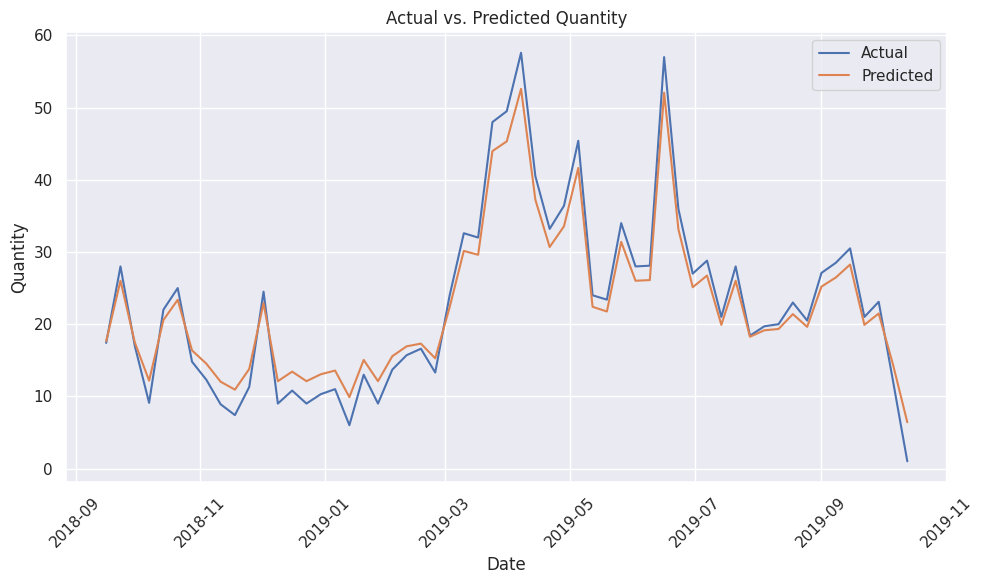

In [157]:
# Make predictions on the test data
predictions = model.predict(X_test8)

# Inverse transform the predictions
predicted_values = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()

# Inverse transform the actual values
actual_values = scaler_y.inverse_transform(y_test8.reshape(-1, 1)).flatten()

# Plot actual vs. predicted values with 'datum' on the x-axis
plt.figure(figsize=(10, 6))
plt.plot(test8['datum'], actual_values, label='Actual')
plt.plot(test8['datum'], predicted_values, label='Predicted')
plt.title('Actual vs. Predicted Quantity')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

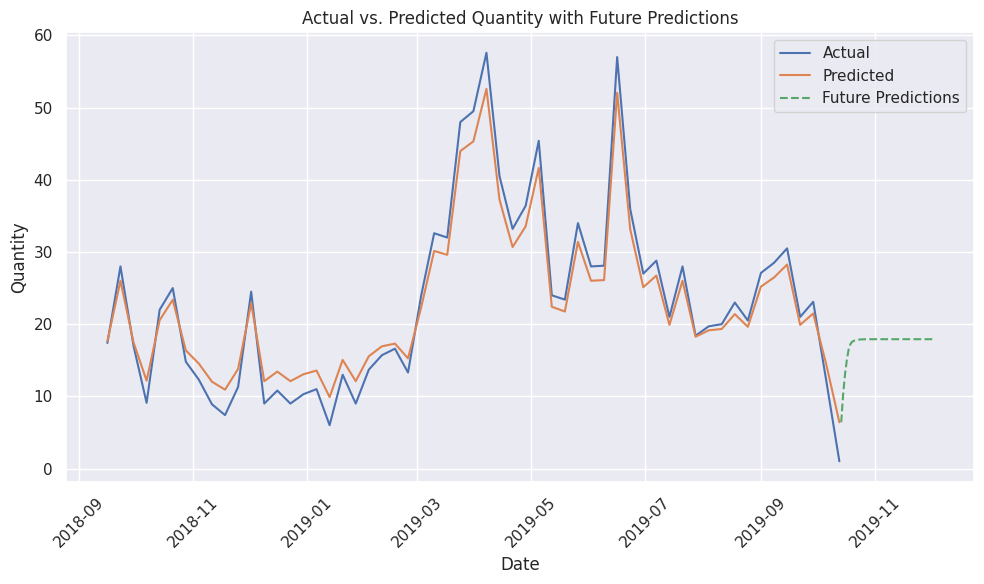

In [158]:
# Number of future time steps to predict
future_steps = 50  # Adjust as needed

# Prepare the last window of data from the test set to predict future values
last_window = X_test8[-1].reshape(1, -1)  # Reshape to match model input shape

# Predict future values iteratively while maintaining the trend
future_predictions = []
for _ in range(future_steps):
    # Predict the next value
    next_pred = model.predict(last_window)
    
    # Append the prediction to the list
    future_predictions.append(next_pred[0])
    
    # Extend the last window by adding the prediction at the end
    last_window = np.append(last_window[:, 1:], next_pred).reshape(1, -1)

# Inverse transform the predicted future values
future_predictions = scaler_y.inverse_transform(np.array(future_predictions).reshape(-1, 1)).flatten()

# Generate future dates for plotting
last_date = pd.to_datetime(test8['datum'].iloc[-1])
future_dates = [last_date + pd.DateOffset(days=i) for i in range(1, future_steps + 1)]

# Plot actual vs. predicted values with future predictions
plt.figure(figsize=(10, 6))
plt.plot(test8['datum'], actual_values, label='Actual')
plt.plot(test8['datum'], predicted_values, label='Predicted')
plt.plot(future_dates, future_predictions, label='Future Predictions', linestyle='--')
plt.title('Actual vs. Predicted Quantity with Future Predictions')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()
